# Predicción de Lluvia en Australia — PCA como Preprocesamiento para Clasificación
**Grupo 3 | Inteligencia Artificial I — Actividad 3**

Integrantes:
- Ariza Vargas Sariaht Eyleen Xiomara — modelo y notebook
- Carreño Medina Adriana Lucia — app web y despliegue
- Linares Viasus Brandon Felipe — documentación y presentación

**Fundación Universitaria Los Libertadores — 2024**

---

### Pipeline completo
```
Datos crudos → EDA → Outliers → Preprocesamiento → StandardScaler → PCA → LogisticRegression → Evaluación → Serialización
```

## 1. Introducción

El dataset *Rain in Australia* (Kaggle, 2017) contiene 145 460 observaciones meteorológicas diarias registradas durante 10 años en 49 estaciones distribuidas por todo el territorio australiano [1]. El objetivo es predecir si lloverá al día siguiente (`RainTomorrow`) a partir de las condiciones observadas durante el día actual.

Lo que hace interesante este problema para PCA es la **alta redundancia entre variables**: la temperatura de las 9am y las 3pm tienen correlación r > 0.97, la presión de ambos horarios supera r = 0.96, y todas las mediciones de temperatura están correlacionadas entre sí con r > 0.85. Cuando el clasificador recibe 17 variables con esa estructura, parte de su capacidad de aprendizaje se gasta en redundancia en lugar de en información nueva.

PCA (*Principal Component Analysis*) resuelve ese problema: encuentra las direcciones del espacio de características donde los datos varían más, proyecta todos los puntos sobre esos ejes ortogonales y descarta las direcciones de menor varianza. El resultado son variables nuevas —los componentes principales— que no están correlacionadas entre sí y que concentran la mayor parte de la información original en pocos ejes.

Este enfoque tiene aplicaciones directas en meteorología operacional. Hannachi et al. (2007) demuestran que PCA es la herramienta estándar en climatología para extraer los modos dominantes de variabilidad atmosférica y reducir la dimensionalidad de campos de presión, temperatura y precipitación antes de cualquier análisis predictivo [5]. Jolliffe y Cadima (2016) revisan su evolución y muestran que sigue siendo el método de referencia para preprocesamiento en ciencias del clima exactamente por este tipo de correlación estructural entre variables [6].

## 2. Fundamentos Matemáticos

### 2.1 Estandarización previa

PCA es sensible a la escala. Antes de aplicarlo, cada variable $x_j$ se transforma a media 0 y desviación estándar 1:

$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

Sin este paso, variables en escalas distintas (por ejemplo `Pressure` en hPa ≈ 1010 vs `Cloud` en oktas 0–8) dominarían los componentes por su magnitud, no por su varianza informativa.

### 2.2 Matriz de covarianza

Dado un conjunto de $n$ observaciones con $p$ variables estandarizadas, la matriz de covarianza $\mathbf{C}$ de dimensión $p \times p$ captura las relaciones lineales entre variables:

$$\mathbf{C} = \frac{1}{n-1}\,\mathbf{Z}^\top \mathbf{Z}$$

donde $\mathbf{Z}$ es la matriz de datos estandarizados. Cuando $C_{ij}$ es grande, las variables $i$ y $j$ se mueven juntas — exactamente la redundancia que PCA va a eliminar.

### 2.3 Descomposición en valores propios

PCA resuelve el problema de eigenvalores:

$$\mathbf{C}\,\mathbf{v}_k = \lambda_k\,\mathbf{v}_k$$

donde $\lambda_k$ es el $k$-ésimo valor propio y $\mathbf{v}_k$ es el vector propio asociado (el $k$-ésimo componente principal). Los vectores propios son ortogonales entre sí, lo que garantiza que los componentes no tengan correlación. Cada $\lambda_k$ mide cuánta varianza captura ese componente.

### 2.4 Varianza explicada acumulada

La proporción de varianza explicada por los primeros $k$ componentes es:

$$\text{VE}(k) = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{i=1}^{p} \lambda_i}$$

Usamos `PCA(n_components=0.95)` para retener automáticamente los $k$ componentes que explican al menos el 95% de la varianza total.

### 2.5 Pseudocódigo

*Adaptado de Jolliffe y Cadima (2016) [6].*

```
PCA_Preprocesamiento(X_train, X_test, varianza_objetivo=0.95):
  // Paso 1 — Estandarizar (fit solo sobre train)
  μ, σ  = media y desviacion_std de X_train por columna
  Z_train = (X_train - μ) / σ
  Z_test  = (X_test  - μ) / σ   // mismas μ y σ, sin data leakage

  // Paso 2 — Matriz de covarianza
  C = (1/(n-1)) * Z_train^T * Z_train

  // Paso 3 — Eigendescomposicion
  [λ_1,...,λ_p], [v_1,...,v_p] = eigen(C)   // ordenados de mayor a menor λ

  // Paso 4 — Seleccion de componentes
  k = min k tal que sum(λ_1..λ_k) / sum(λ_1..λ_p) >= varianza_objetivo

  // Paso 5 — Proyeccion
  W = [v_1, ..., v_k]           // matriz de proyeccion (p × k)
  X_train_pca = Z_train * W     // (n_train × k)
  X_test_pca  = Z_test  * W     // (n_test  × k)

  return X_train_pca, X_test_pca, k
```

## 3. Importaciones

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

# Paleta cualitativa ColorBrewer Set2 (hex exactos — Unidad 2)
SET2 = [
    "#66C2A5",  # teal
    "#FC8D62",  # naranja
    "#8DA0CB",  # azul-violeta
    "#E78AC3",  # rosa
    "#A6D854",  # verde-lima
    "#FFD92F",  # amarillo
    "#E5C494",  # beige
    "#B3B3B3",  # gris
]

print('Librerías importadas correctamente ✓')

Librerías importadas correctamente ✓


## 4. Carga de Datos

**Fuente:** [Kaggle — Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package) [1]

El dataset contiene observaciones diarias del Bureau of Meteorology de Australia [2]. Para descargarlo:
1. Crear cuenta gratuita en Kaggle
2. Descargar desde la URL anterior
3. Colocar `weatherAUS.csv` en la carpeta `data/raw/`

In [2]:
DATA_PATH = '../data/raw/weatherAUS.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nColumnas: {list(df.columns)}')
df.head()

Dataset cargado: 145,460 filas × 23 columnas

Columnas: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 5. Análisis Exploratorio de Datos (EDA)

In [3]:
# Información general y valores nulos
print('=== Información del Dataset ===')
print(df.dtypes.to_string())
print('\n=== Estadísticas Descriptivas ===')
print(df.describe().round(2).to_string())

print('\n=== Valores Nulos por Variable ===')
nulls = df.isnull().sum().sort_values(ascending=False)
null_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, '% del total': null_pct})
print(null_df[null_df['Nulos'] > 0].to_string())

=== Información del Dataset ===
Date                 str
Location             str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
RainTomorrow         str

=== Estadísticas Descriptivas ===
         MinTemp    MaxTemp   Rainfall  Evaporation  Sunshine  WindGustSpeed  WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  Cloud3pm    Temp9am    Temp3pm
count  143975.00  144199.00  142199.00     82670.00  75625.00      135197.00     143693.00     142398.00    142806.00    140953.00    130395.00    130432.00  8

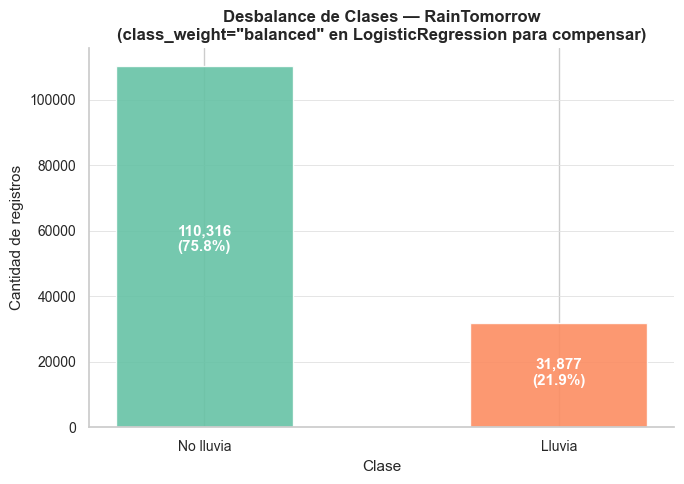

In [4]:
# Distribución de la variable objetivo (Unidad 1: barra para categórica — NO pie chart)
os.makedirs('../data/processed', exist_ok=True)

target_counts = df['RainTomorrow'].value_counts()
labels_bar = ['No lluvia', 'Lluvia']
bar_colors = [SET2[0], SET2[1]]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_bar, target_counts.values,
              color=bar_colors, edgecolor='white', alpha=0.90, width=0.5)

ax.set_title('Desbalance de Clases — RainTomorrow\n'
             '(class_weight="balanced" en LogisticRegression para compensar)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Clase', fontsize=11)
ax.set_ylabel('Cantidad de registros', fontsize=11)
ax.tick_params(labelsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.6)
ax.set_axisbelow(True)

# Anotación dentro de la barra (no encima, para no tapar el título)
for bar, v in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            v * 0.52,                        # centrado vertical dentro de la barra
            f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', va='center',
            fontweight='bold', fontsize=11,
            color='white')

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

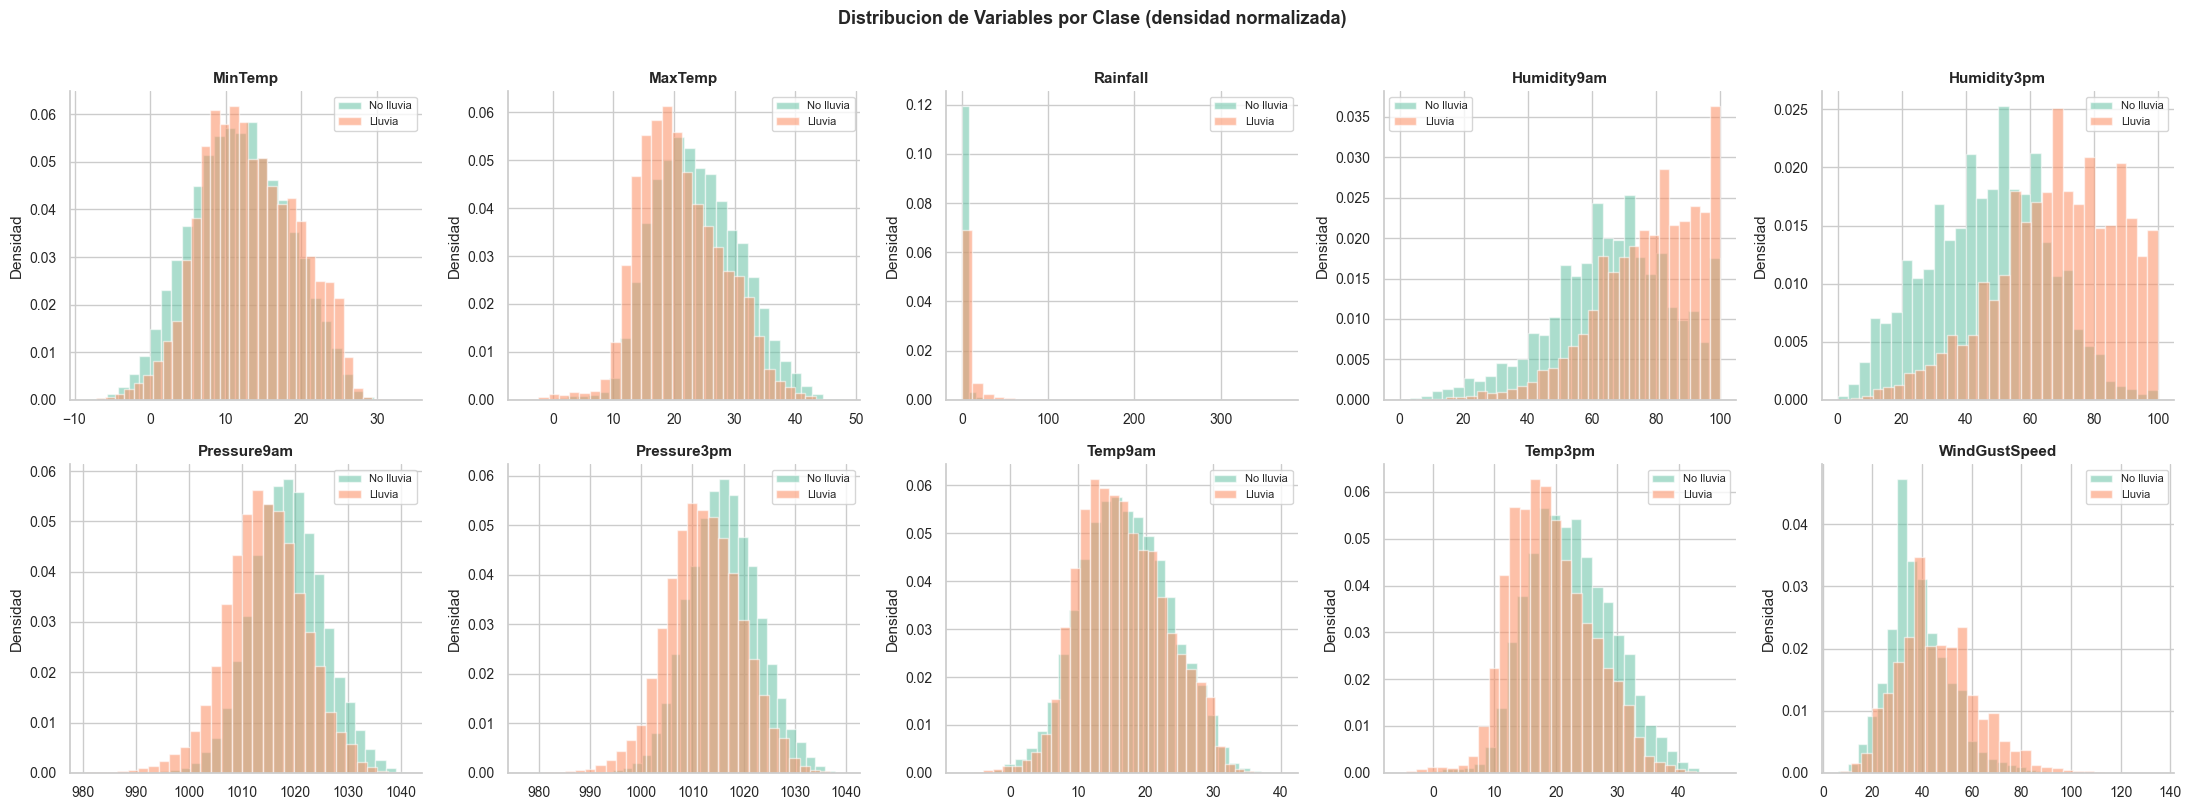

In [5]:
# Distribuciones de variables numéricas por clase
# Unidad 2: SET2[0]/SET2[1] para dos categorías — Unidad 3: spines + tick_params
NUM_FEATURES = ['MinTemp', 'MaxTemp', 'Rainfall', 'Humidity9am', 'Humidity3pm',
                'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'WindGustSpeed']

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

for i, feat in enumerate(NUM_FEATURES):
    no_rain = df[df['RainTomorrow'] == 'No'][feat].dropna()
    rain    = df[df['RainTomorrow'] == 'Yes'][feat].dropna()
    axes[i].hist(no_rain, alpha=0.55, label='No lluvia', color=SET2[0], bins=30, density=True)
    axes[i].hist(rain,    alpha=0.55, label='Lluvia',    color=SET2[1], bins=30, density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densidad', fontsize=11)
    axes[i].tick_params(labelsize=10)
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribucion de Variables por Clase (densidad normalizada)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Análisis de Valores Atípicos (Outliers)

Se utiliza el método IQR (Rango Intercuartílico) para detectar outliers en cada variable numérica.
Un valor se considera atípico si cae fuera del rango $[Q_1 - 1.5 \times IQR,\; Q_3 + 1.5 \times IQR]$.

Los outliers meteorológicos representan **eventos climáticos extremos reales** (olas de calor, tormentas, etc.) y se conservan en el dataset. El uso de `StandardScaler` en el pipeline mitiga su influencia sobre PCA al normalizar las escalas.

=== Outliers por variable (método IQR) ===
      Feature  Outliers  % del total
     Rainfall     25578        17.99
  Evaporation      1995         2.41
WindGustSpeed      3092         2.29
 WindSpeed3pm      2523         1.77
 WindSpeed9am      1817         1.26
  Humidity9am      1425         1.00
  Pressure9am      1191         0.91
  Pressure3pm       919         0.70
      Temp3pm       764         0.54
      MaxTemp       489         0.34
      Temp9am       262         0.18
      MinTemp        54         0.04
     Sunshine         0         0.00
  Humidity3pm         0         0.00
     Cloud9am         0         0.00
     Cloud3pm         0         0.00


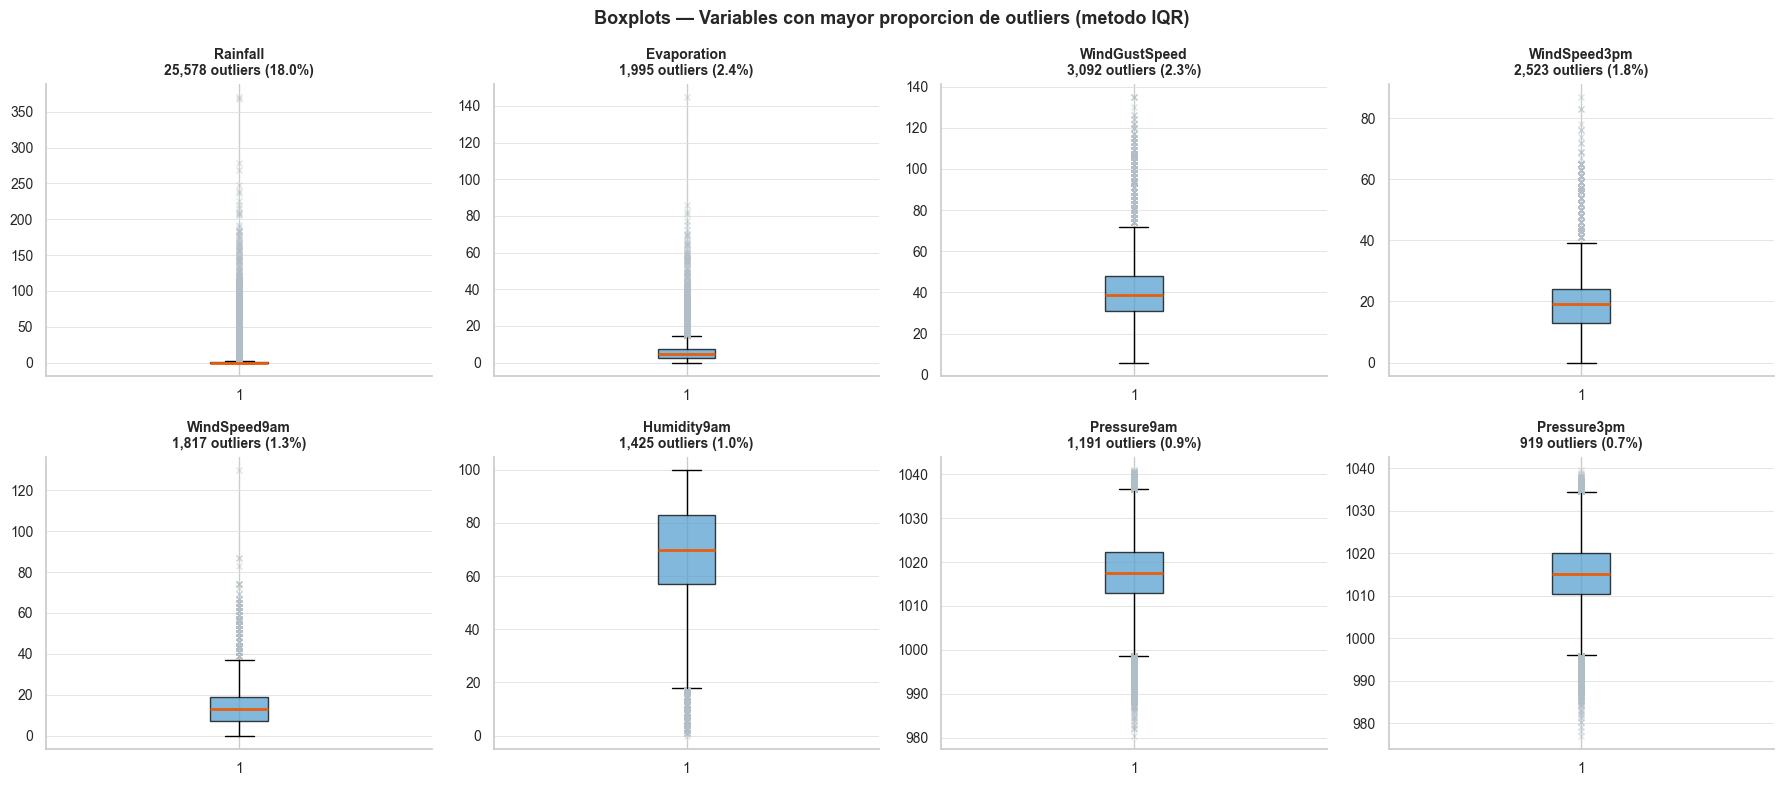


→ Decisión: los outliers se conservan (son eventos extremos reales).
  StandardScaler en el pipeline normaliza su efecto sobre PCA.


In [6]:
NUMERICAL_ALL = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
                 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
                 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

outlier_summary = []
for col in NUMERICAL_ALL:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_outliers / df[col].notna().sum() * 100
    outlier_summary.append({'Feature': col, 'Q1': round(q1,2), 'Q3': round(q3,2),
                             'IQR': round(iqr,2), 'Límite inf': round(lower,2),
                             'Límite sup': round(upper,2),
                             'Outliers': n_outliers, '% del total': round(pct, 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('% del total', ascending=False)
print('=== Outliers por variable (método IQR) ===')
print(outlier_df[['Feature', 'Outliers', '% del total']].to_string(index=False))

# Boxplots — Unidad 2: Blues secuencial para caja, #B0BEC5+x para outliers (ruido)
# Unidad 3: spines, tick_params
top_feats = outlier_df.head(8)['Feature'].tolist()
box_color  = sns.color_palette("Blues", 8)[4]    # azul medio — secuencial
med_color  = sns.color_palette("Oranges_d", 3)[1] # naranja — nunca rojo

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    axes[i].boxplot(df[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=box_color, alpha=0.75),
                    medianprops=dict(color=med_color, linewidth=2),
                    flierprops=dict(marker='x', markerfacecolor='#B0BEC5',
                                    markeredgecolor='#B0BEC5',
                                    markersize=4, alpha=0.4))
    row = outlier_df[outlier_df['Feature'] == feat].iloc[0]
    axes[i].set_title(f'{feat}\n{row["Outliers"]:,} outliers ({row["% del total"]:.1f}%)',
                      fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=10)
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].yaxis.grid(True, color='#E0E0E0', linewidth=0.6)
    axes[i].set_axisbelow(True)

plt.suptitle('Boxplots — Variables con mayor proporcion de outliers (metodo IQR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n→ Decisión: los outliers se conservan (son eventos extremos reales).')
print('  StandardScaler en el pipeline normaliza su efecto sobre PCA.')

### 5.4 Matriz de Correlación — Evidencia para PCA

La correlación lineal entre variables justifica el uso de PCA. Cuando dos variables tienen $r > 0.9$, están midiendo prácticamente lo mismo: PCA detecta esa redundancia y la colapsa en un único componente.

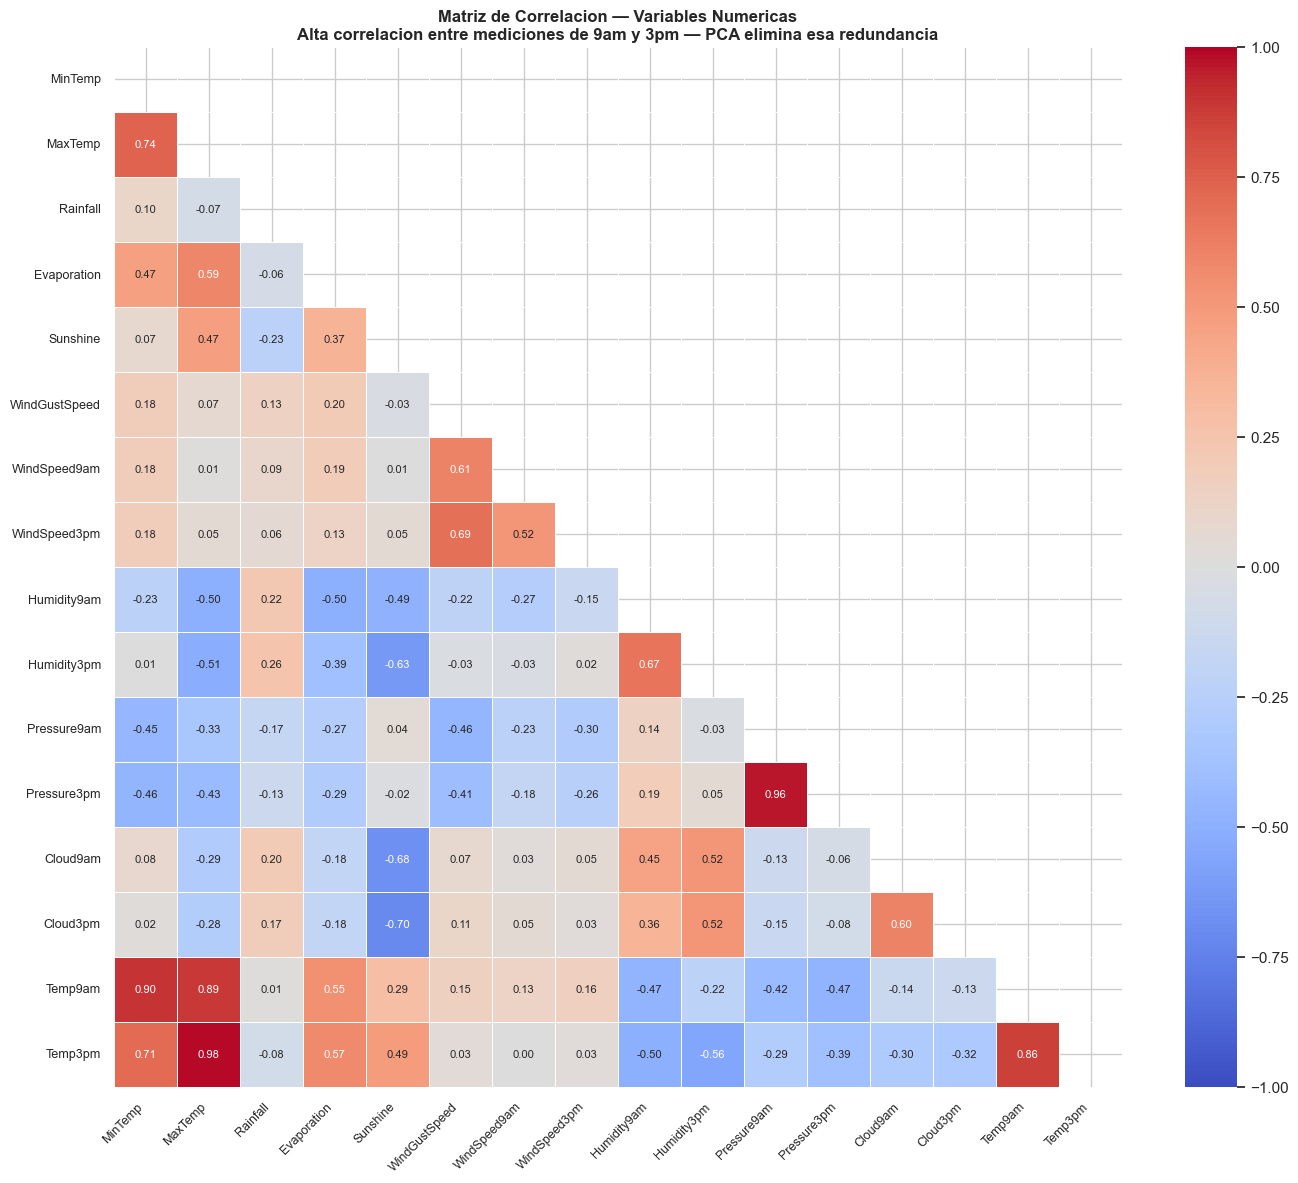

Correlaciones mas altas detectadas:
  MaxTemp              <-> Temp3pm             : r = 0.985
  Pressure3pm          <-> Pressure9am         : r = 0.961
  MinTemp              <-> Temp9am             : r = 0.902
  MaxTemp              <-> Temp9am             : r = 0.887
  Temp3pm              <-> Temp9am             : r = 0.861

-> Estas correlaciones confirman que PCA reducira la dimensionalidad sin perder informacion relevante.


In [7]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = df[NUMERICAL_ALL].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1)
ax.set_title('Matriz de Correlacion — Variables Numericas\n'
             'Alta correlacion entre mediciones de 9am y 3pm — PCA elimina esa redundancia',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlaciones mas altas detectadas:')
pairs = [(r, c) for r in NUMERICAL_ALL for c in NUMERICAL_ALL if r < c]
high_corr = [(r, c, corr.loc[r, c]) for r, c in pairs if abs(corr.loc[r, c]) > 0.80]
high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for r, c, v in high_corr[:8]:
    print(f'  {r:20} <-> {c:20}: r = {v:.3f}')
print('\n-> Estas correlaciones confirman que PCA reducira la dimensionalidad sin perder informacion relevante.')

## 6. Preprocesamiento

El preprocesamiento sigue un orden estricto para evitar **data leakage**: el `StandardScaler` y el `PCA` se ajustan **únicamente sobre el conjunto de entrenamiento** y luego se aplican al conjunto de prueba usando los parámetros ya calculados. Ajustar sobre todo el dataset filtraría información del test hacia el train, produciendo métricas artificialmente altas [3].

In [8]:
# Features: 16 numéricas + RainToday binaria = 17 features totales
FEATURES = NUMERICAL_ALL + ['RainToday']
TARGET   = 'RainTomorrow'

data = df[FEATURES + [TARGET]].copy()
data = data.dropna(subset=[TARGET])
print(f'Registros con target válido: {len(data):,}')

# Codificar variables binarias
data['RainToday'] = data['RainToday'].map({'Yes': 1, 'No': 0})
data[TARGET]      = data[TARGET].map({'Yes': 1, 'No': 0})

# Imputar nulos con la mediana de cada columna (asignación directa — pandas 3.x CoW)
medians = data[NUMERICAL_ALL].median()
data[NUMERICAL_ALL] = data[NUMERICAL_ALL].fillna(medians)
data['RainToday'] = data['RainToday'].fillna(0)

print(f'Valores nulos restantes: {data.isnull().sum().sum()}')

X = data[FEATURES]
y = data[TARGET]

# Guardar rangos para la app (mediana como valor por defecto en sliders)
feature_ranges = {
    col: {
        'min':    float(X[col].min()),
        'max':    float(X[col].max()),
        'mean':   float(X[col].mean()),
        'median': float(X[col].median()),
    }
    for col in FEATURES
}

print(f'\nX shape: {X.shape}')
print(f'Distribución objetivo — No lluvia: {(y==0).sum():,} | Lluvia: {(y==1).sum():,}')
print(f'Ratio desbalance: {(y==0).sum()/(y==1).sum():.2f}:1')

Registros con target válido: 142,193
Valores nulos restantes: 0

X shape: (142193, 17)
Distribución objetivo — No lluvia: 110,316 | Lluvia: 31,877
Ratio desbalance: 3.46:1


In [9]:
# División train/test estratificada (mantiene la proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]:,} muestras | Test: {X_test.shape[0]:,} muestras')
print(f'Proporción lluvia en train: {y_train.mean()*100:.1f}%')
print(f'Proporción lluvia en test:  {y_test.mean()*100:.1f}% (estratificado ✓)')

# Estandarizar — fit SOLO sobre train (evita data leakage)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)      # mismo scaler, sin re-fit
print(f'\nEstandarizado — media train: {X_train_s.mean():.6f} (≈0) | std train: {X_train_s.std():.6f} (≈1)')

Train: 113,754 muestras | Test: 28,439 muestras
Proporción lluvia en train: 22.4%
Proporción lluvia en test:  22.4% (estratificado ✓)

Estandarizado — media train: -0.000000 (≈0) | std train: 1.000000 (≈1)


## 7. Aplicación de PCA

### ¿Por qué PCA tiene sentido en este dataset?

Las 17 variables meteorológicas presentan alta correlación estructural:
- `Temp9am` y `Temp3pm` (r ≈ 0.98) — miden temperatura del mismo día en horarios distintos
- `Pressure9am` y `Pressure3pm` (r ≈ 0.96) — la presión varía poco en 6 horas
- `MinTemp`, `MaxTemp`, `Temp9am`, `Temp3pm` (r > 0.85 entre todas) — temperatura del mismo día

PCA colapsa estas correlaciones en componentes ortogonales independientes, pasando de 17 variables redundantes a 7-9 componentes que explican el 95% de la varianza. El clasificador trabaja en un espacio más compacto, sin redundancia, lo que facilita encontrar la frontera de decisión.

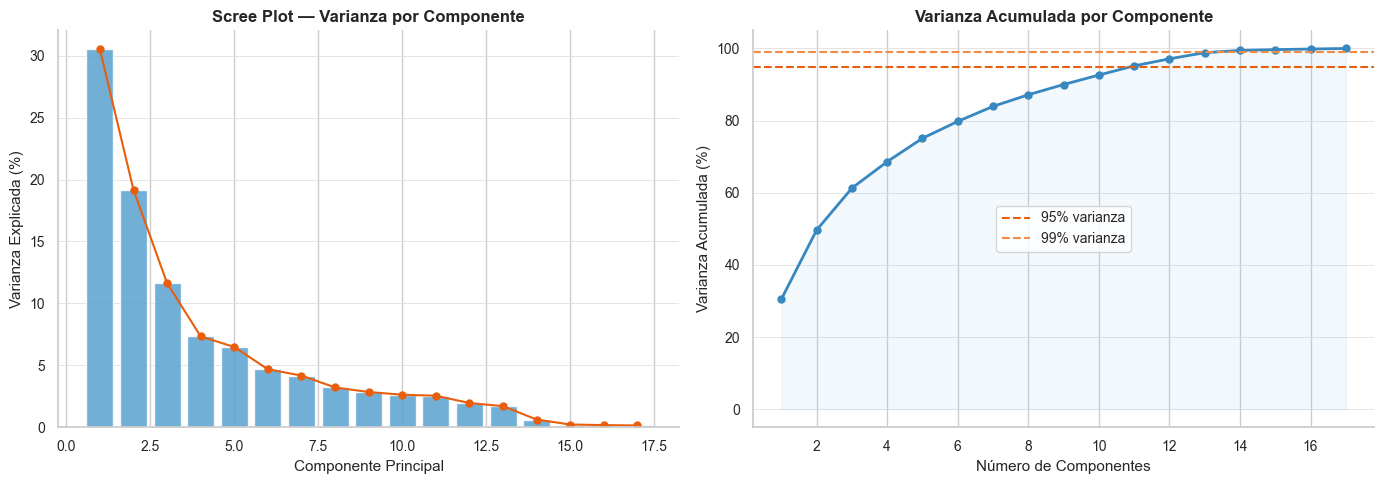

Componentes para 95% de varianza: 11  (de 17 originales)
Componentes para 99% de varianza: 14
Reducción con 95%: 17 → 11 dimensiones (35.3% menos)

Varianza explicada por componente:
  PC1: 30.51%  (acumulado: 30.51%)
  PC2: 19.16%  (acumulado: 49.67%)
  PC3: 11.63%  (acumulado: 61.29%)
  PC4:  7.34%  (acumulado: 68.63%)
  PC5:  6.48%  (acumulado: 75.10%)
  PC6:  4.68%  (acumulado: 79.78%)
  PC7:  4.17%  (acumulado: 83.95%)
  PC8:  3.21%  (acumulado: 87.17%)
  PC9:  2.84%  (acumulado: 90.01%)
  PC10:  2.63%  (acumulado: 92.64%)
  PC11:  2.55%  (acumulado: 95.18%)


In [10]:
# Análisis completo de varianza explicada
# Unidad 2: Blues secuencial para barras, Oranges_d para referencias — NUNCA rojo
# Unidad 3: spines, tick_params
pca_full = PCA()
pca_full.fit(X_train_s)

ev  = pca_full.explained_variance_ratio_
cum = np.cumsum(ev)

bar_color  = sns.color_palette("Blues", 8)[4]       # azul medio
line_color = sns.color_palette("Blues_d", 3)[1]     # azul oscuro — línea principal
codo_color = sns.color_palette("Oranges_d", 3)[1]   # naranja — referencia (nunca rojo)
fill_color = sns.color_palette("Blues", 8)[2]       # azul claro — relleno

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (varianza por componente)
axes[0].bar(range(1, len(ev)+1), ev*100, color=bar_color, edgecolor='white', alpha=0.85)
axes[0].plot(range(1, len(ev)+1), ev*100, color=codo_color, marker='o', markersize=5, linewidth=1.5)
axes[0].set_xlabel('Componente Principal', fontsize=11)
axes[0].set_ylabel('Varianza Explicada (%)', fontsize=11)
axes[0].set_title('Scree Plot — Varianza por Componente', fontsize=12, fontweight='bold')
axes[0].tick_params(labelsize=10)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].yaxis.grid(True, color='#E0E0E0', linewidth=0.6)
axes[0].set_axisbelow(True)

# Varianza acumulada
axes[1].plot(range(1, len(cum)+1), cum*100, color=line_color, marker='o', linewidth=2, markersize=5)
axes[1].axhline(y=95, color=codo_color,    linestyle='--', lw=1.5, label='95% varianza')
axes[1].axhline(y=99, color=sns.color_palette("Oranges_d", 3)[0], linestyle='--', lw=1.5, label='99% varianza')
axes[1].fill_between(range(1, len(cum)+1), cum*100, color=fill_color, alpha=0.15)
axes[1].set_xlabel('Número de Componentes', fontsize=11)
axes[1].set_ylabel('Varianza Acumulada (%)', fontsize=11)
axes[1].set_title('Varianza Acumulada por Componente', fontsize=12, fontweight='bold')
axes[1].tick_params(labelsize=10)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(fontsize=10)
axes[1].yaxis.grid(True, color='#E0E0E0', linewidth=0.6)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('../data/processed/pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

n_95 = np.argmax(cum >= 0.95) + 1
n_99 = np.argmax(cum >= 0.99) + 1
print(f'Componentes para 95% de varianza: {n_95}  (de {X.shape[1]} originales)')
print(f'Componentes para 99% de varianza: {n_99}')
print(f'Reducción con 95%: {X.shape[1]} → {n_95} dimensiones ({(1-n_95/X.shape[1])*100:.1f}% menos)')

print(f'\nVarianza explicada por componente:')
for i in range(n_95):
    print(f'  PC{i+1}: {ev[i]*100:5.2f}%  (acumulado: {cum[i]*100:.2f}%)')

In [11]:
# Aplicar PCA con 95% de varianza
pca = PCA(n_components=0.95, random_state=42)
X_train_p = pca.fit_transform(X_train_s)   # fit solo sobre train
X_test_p  = pca.transform(X_test_s)        # transform con los mismos ejes

print(f'Dimensiones originales : {X_train_s.shape[1]} features')
print(f'Dimensiones reducidas  : {pca.n_components_} componentes')
print(f'Varianza preservada    : {sum(pca.explained_variance_ratio_)*100:.2f}%')
print(f'\nLos componentes principales son ortogonales entre sí:')
print(f'  Correlación PC1-PC2: {np.corrcoef(X_train_p[:,0], X_train_p[:,1])[0,1]:.6f} (≈ 0)')

Dimensiones originales : 17 features
Dimensiones reducidas  : 11 componentes
Varianza preservada    : 95.18%

Los componentes principales son ortogonales entre sí:
  Correlación PC1-PC2: -0.000000 (≈ 0)


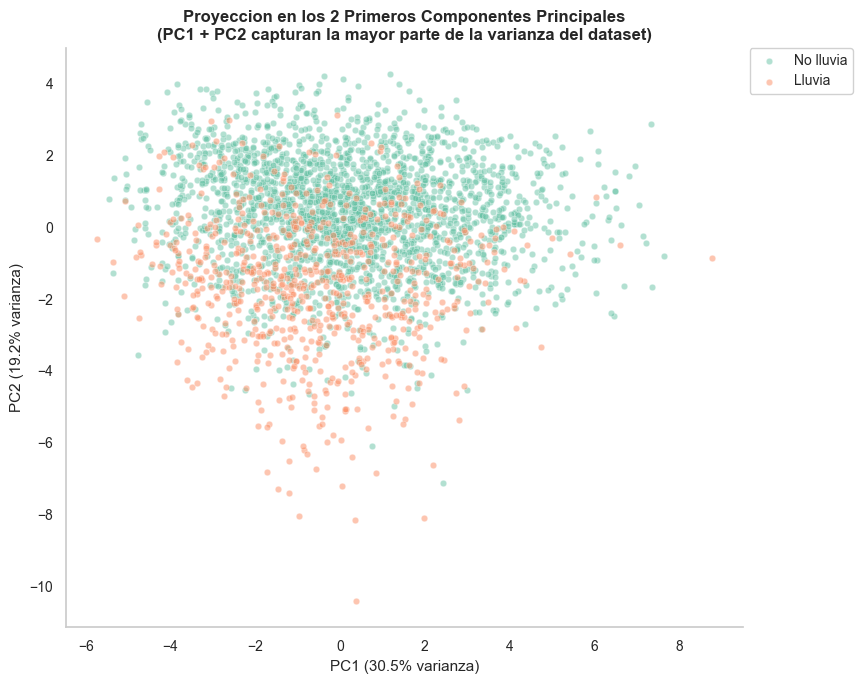

In [12]:
# Visualización en los 2 primeros componentes principales
# Unidad 2: SET2[0]/SET2[1] para clases binarias — Unidad 3: grid(False), facecolor, spines
idx_s = np.random.choice(len(X_train_p), min(3000, len(X_train_p)), replace=False)

fig, ax = plt.subplots(figsize=(10, 7))
for cls, color, label in [(0, SET2[0], 'No lluvia'), (1, SET2[1], 'Lluvia')]:
    mask = y_train.values[idx_s] == cls
    ax.scatter(X_train_p[idx_s][mask, 0], X_train_p[idx_s][mask, 1],
               color=color, label=label, alpha=0.50,
               edgecolors='white', linewidth=0.4, s=22)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Proyeccion en los 2 Primeros Componentes Principales\n'
             '(PC1 + PC2 capturan la mayor parte de la varianza del dataset)',
             fontsize=12, fontweight='bold')
ax.tick_params(labelsize=10)
ax.legend(fontsize=10, framealpha=0.9,
          bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
ax.set_facecolor("white")
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig('../data/processed/pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Interpretación de los Componentes Principales (Loadings)

Los **loadings** (componentes de los vectores propios) indican qué variables originales contribuyen más a cada componente principal. Un loading alto en valor absoluto indica una contribución importante de esa variable al componente.

Top 5 variables que más aportan a cada uno de los primeros 4 componentes:

  PC1 (30.5% varianza):
    + MaxTemp              | loading = 0.397
    + Temp3pm              | loading = 0.391
    + Temp9am              | loading = 0.378
    + MinTemp              | loading = 0.311
    − Humidity9am          | loading = -0.299

  PC2 (19.2% varianza):
    + Pressure9am          | loading = 0.358
    + Pressure3pm          | loading = 0.315
    − WindGustSpeed        | loading = -0.310
    − RainToday            | loading = -0.304
    − Cloud9am             | loading = -0.297

  PC3 (11.6% varianza):
    + WindSpeed9am         | loading = 0.443
    + WindGustSpeed        | loading = 0.443
    + WindSpeed3pm         | loading = 0.435
    − MinTemp              | loading = -0.278
    − Temp9am              | loading = -0.234

  PC4 (7.3% varianza):
    + Rainfall             | loading = 0.517
    + RainToday            | loading = 0.470
    − Cloud3pm             | loading = -0.414
    − Clou

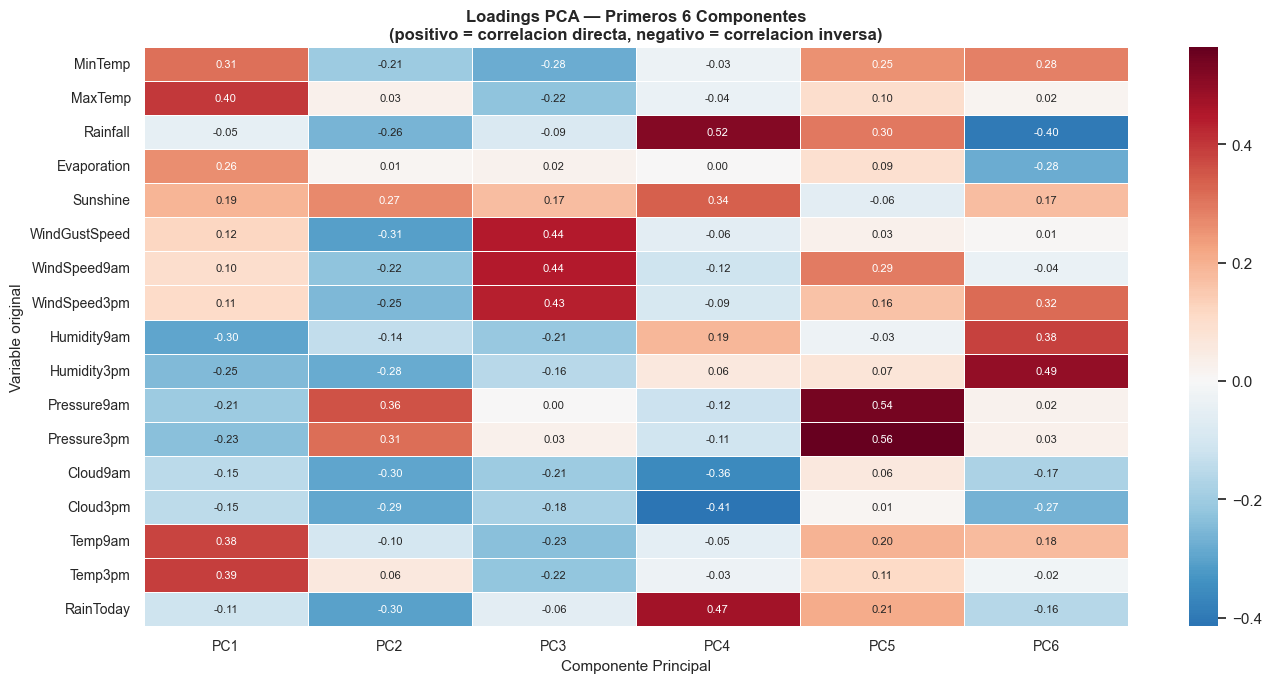

In [13]:
# Matriz de loadings: filas = features originales, columnas = componentes PCA
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print('Top 5 variables que más aportan a cada uno de los primeros 4 componentes:')
for pc in [f'PC{i+1}' for i in range(min(4, pca.n_components_))]:
    top = loadings[pc].abs().nlargest(5)
    ve  = pca.explained_variance_ratio_[int(pc[2:])-1] * 100
    print(f'\n  {pc} ({ve:.1f}% varianza):')
    for feat, val in top.items():
        direction = '+' if loadings.loc[feat, pc] > 0 else '−'
        print(f'    {direction} {feat:20} | loading = {loadings.loc[feat, pc]:.3f}')

# Heatmap de loadings — Unidad 2: RdBu_r (divergente, punto neutro en 0)
n_show = min(6, pca.n_components_)
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(loadings.iloc[:, :n_show], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.4, annot_kws={'size': 8})
ax.set_title(f'Loadings PCA — Primeros {n_show} Componentes\n'
             '(positivo = correlacion directa, negativo = correlacion inversa)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Variable original', fontsize=11)
ax.set_xlabel('Componente Principal', fontsize=11)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig('../data/processed/pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Entrenamiento

Se usa **Regresión Logística** con `class_weight='balanced'` para compensar el desbalance de clases (77.7% No lluvia / 22.3% Lluvia). Sin este parámetro, el modelo tendería a predecir siempre "No lluvia" y obtendría un accuracy artificialmente alto sin aprender la clase minoritaria.

In [14]:
# Entrenar clasificador sobre el espacio PCA
classifier = LogisticRegression(
    random_state=42,
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs'
)
classifier.fit(X_train_p, y_train)
print('Modelo entrenado ✓')

# Validación cruzada 5-fold con el pipeline completo
# Pipeline completo garantiza que no haya data leakage en cross-validation
pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=42)),
    ('clf',    LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1  = cross_val_score(pipeline_cv, X, y, cv=cv, scoring='f1')
cv_auc = cross_val_score(pipeline_cv, X, y, cv=cv, scoring='roc_auc')

print(f'\nValidación cruzada estratificada (5-fold):')
print(f'  F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  (por fold: {[f"{v:.3f}" for v in cv_f1]})')
print(f'  ROC-AUC   : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}  (por fold: {[f"{v:.3f}" for v in cv_auc]})')

Modelo entrenado ✓



Validación cruzada estratificada (5-fold):
  F1-Score  : 0.5954 ± 0.0022  (por fold: ['0.598', '0.595', '0.592', '0.597', '0.596'])
  ROC-AUC   : 0.8470 ± 0.0022  (por fold: ['0.849', '0.846', '0.844', '0.849', '0.847'])


## 9. Análisis de Hiperparámetros — Efecto de n_components

Se evalúa cómo cambia el rendimiento del modelo al variar la cantidad de componentes PCA retenidos. Esto permite verificar que el valor elegido (0.95) es el más adecuado.

Configuración  Componentes   Accuracy   F1         ROC-AUC
--------------------------------------------------------------
2 comp.        2 features    0.7590    0.5794    0.8333
4 comp.        4 features    0.7634    0.5863    0.8380
6 comp.        6 features    0.7627    0.5897    0.8421
90% var.       9 features    0.7675    0.5946    0.8461


95% var.       11 features   0.7697    0.5975    0.8492 ← elegido
99% var.       14 features   0.7858    0.6147    0.8617
Sin PCA        17 features   0.7906    0.6226    0.8663


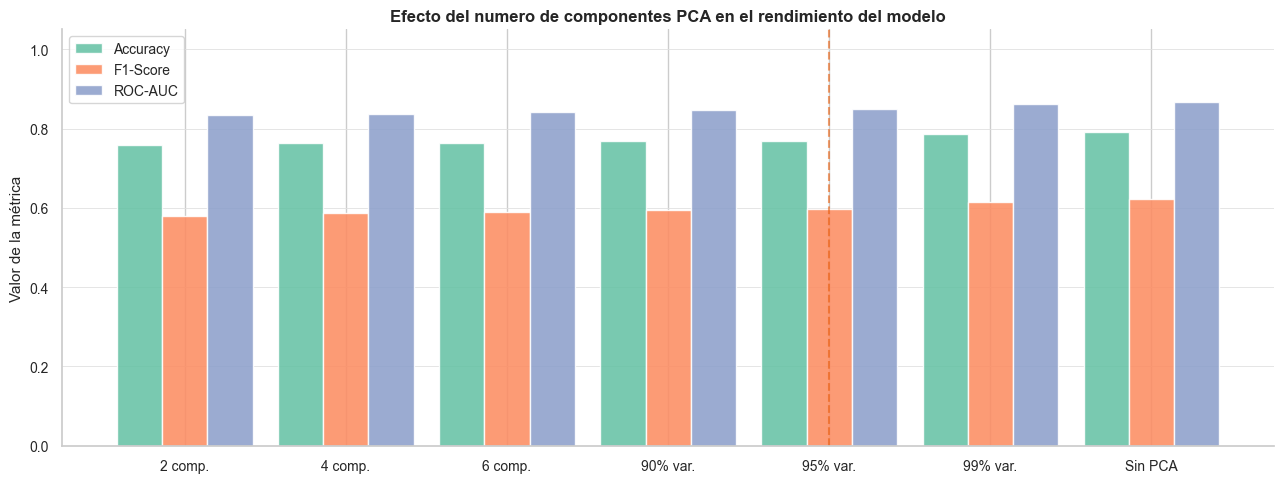


→ PCA 95% conserva rendimiento comparable al baseline sin PCA, con menos dimensiones.


In [15]:
# Probar distintas configuraciones de n_components
configs = [
    ('2 comp.',  2),
    ('4 comp.',  4),
    ('6 comp.',  6),
    ('90% var.', 0.90),
    ('95% var.', 0.95),   # <- configuración elegida
    ('99% var.', 0.99),
    ('Sin PCA',  None),   # baseline: regresión logística sin PCA
]

resultados = []
print(f'{"Configuración":<14} {"Componentes":<13} {"Accuracy":<10} {"F1":<10} {"ROC-AUC"}')
print('-' * 62)

for nombre, n_comp in configs:
    if n_comp is None:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'))
        ])
    else:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=n_comp, random_state=42)),
            ('clf',    LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'))
        ])

    pipe.fit(X_train, y_train)
    y_pred_c = pipe.predict(X_test)
    y_prob_c = pipe.predict_proba(X_test)[:, 1]

    acc_c  = accuracy_score(y_test, y_pred_c)
    f1_c   = f1_score(y_test, y_pred_c)
    auc_c  = roc_auc_score(y_test, y_prob_c)

    if n_comp is None:
        n_real = X_train.shape[1]; label = 'Sin PCA'
    else:
        n_real = pipe.named_steps['pca'].n_components_; label = nombre

    star = ' ← elegido' if n_comp == 0.95 else ''
    print(f'{label:<14} {str(n_real) + " features":<13} {acc_c:.4f}    {f1_c:.4f}    {auc_c:.4f}{star}')
    resultados.append({'config': nombre, 'n_comp': n_real, 'acc': acc_c, 'f1': f1_c, 'auc': auc_c})

# Gráficas comparativas
# Unidad 2: SET2 para 3 métricas — Unidad 3: spines, tick_params
res_df = pd.DataFrame(resultados)
x_labels = res_df['config'].tolist()
x = np.arange(len(x_labels))
width = 0.28

codo_color = sns.color_palette("Oranges_d", 3)[1]

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width, res_df['acc'], width, label='Accuracy', color=SET2[0], alpha=0.88, edgecolor='white')
b2 = ax.bar(x,          res_df['f1'],  width, label='F1-Score', color=SET2[1], alpha=0.88, edgecolor='white')
b3 = ax.bar(x + width, res_df['auc'], width, label='ROC-AUC',  color=SET2[2], alpha=0.88, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10)
ax.tick_params(labelsize=10)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Efecto del numero de componentes PCA en el rendimiento del modelo',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.axvline(x=4, color=codo_color, linestyle='--', alpha=0.6, linewidth=1.5, label='Config. elegida')
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../data/processed/hyperparameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n→ PCA 95% conserva rendimiento comparable al baseline sin PCA, con menos dimensiones.')

## 10. Evaluación del Modelo Final

Para clasificación binaria con desbalance de clases, **F1-Score y ROC-AUC** son métricas más informativas que Accuracy, porque Accuracy puede ser alta simplemente prediciendo siempre la clase mayoritaria.

In [16]:
y_pred = classifier.predict(X_test_p)
y_prob = classifier.predict_proba(X_test_p)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print('=' * 50)
print('       MÉTRICAS DE EVALUACIÓN — CONJUNTO TEST')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 50)
print(f'\nReporte completo por clase:')
print(classification_report(y_test, y_pred, target_names=['No lluvia', 'Lluvia']))

       MÉTRICAS DE EVALUACIÓN — CONJUNTO TEST
  Accuracy  : 0.7697  (76.97%)
  Precision : 0.4912  (49.12%)
  Recall    : 0.7627  (76.27%)
  F1-Score  : 0.5975  (59.75%)
  ROC-AUC   : 0.8492

Reporte completo por clase:
              precision    recall  f1-score   support

   No lluvia       0.92      0.77      0.84     22064
      Lluvia       0.49      0.76      0.60      6375

    accuracy                           0.77     28439
   macro avg       0.70      0.77      0.72     28439
weighted avg       0.82      0.77      0.78     28439



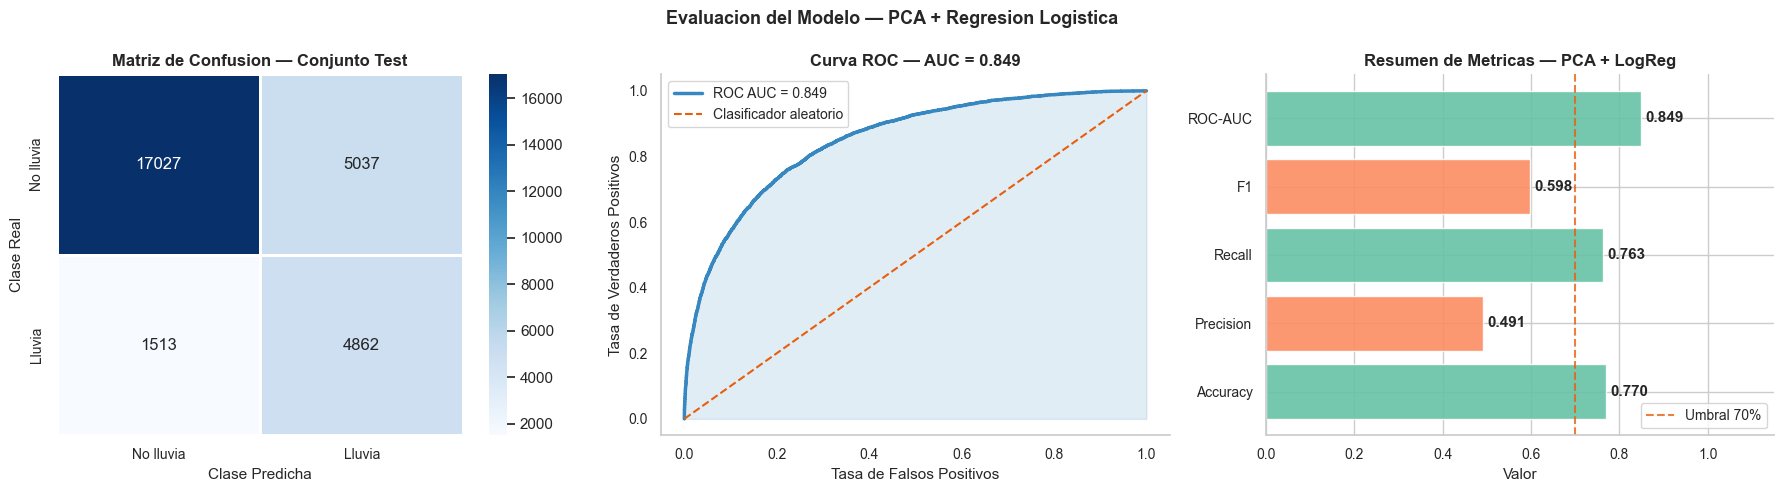

In [17]:
# Unidad 2: sin rojo — referencias en naranja, métricas en SET2
# Unidad 3: spines, tick_params, títulos descriptivos
roc_color  = sns.color_palette("Blues_d", 3)[1]     # línea ROC principal
codo_color = sns.color_palette("Oranges_d", 3)[1]   # referencias — nunca rojo

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No lluvia', 'Lluvia'],
            yticklabels=['No lluvia', 'Lluvia'], linewidths=1)
axes[0].set_title('Matriz de Confusion — Conjunto Test', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Clase Real', fontsize=11)
axes[0].set_xlabel('Clase Predicha', fontsize=11)
axes[0].tick_params(labelsize=10)

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color=roc_color, linewidth=2.5, label=f'ROC AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], color=codo_color, linestyle='--',
             linewidth=1.5, label='Clasificador aleatorio')
axes[1].fill_between(fpr, tpr, alpha=0.15, color=roc_color)
axes[1].set_xlabel('Tasa de Falsos Positivos', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
axes[1].set_title(f'Curva ROC — AUC = {auc:.3f}', fontsize=12, fontweight='bold')
axes[1].tick_params(labelsize=10)
axes[1].legend(fontsize=10)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(False)
axes[1].set_facecolor("white")

# Barras de métricas — Unidad 2: SET2[0]/SET2[2] según umbral (sin rojo-verde)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
values        = [acc, prec, rec, f1, auc]
bar_colors_m  = [SET2[0] if v >= 0.70 else SET2[1] for v in values]
bars = axes[2].barh(metrics_names, values, color=bar_colors_m, edgecolor='white', alpha=0.90)
axes[2].set_xlim(0, 1.15)
axes[2].axvline(x=0.70, color=codo_color, linestyle='--', linewidth=1.5,
                alpha=0.8, label='Umbral 70%')
for bar, v in zip(bars, values):
    axes[2].text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f}', va='center', fontweight='bold', fontsize=11)
axes[2].set_title('Resumen de Metricas — PCA + LogReg', fontsize=12, fontweight='bold')
axes[2].tick_params(labelsize=10)
axes[2].spines[["top", "right"]].set_visible(False)
axes[2].legend(fontsize=10)
axes[2].set_xlabel('Valor', fontsize=11)

plt.suptitle('Evaluacion del Modelo — PCA + Regresion Logistica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Comparación: Con PCA vs Sin PCA (Baseline)

Entrenamos el mismo clasificador sin PCA como línea base para verificar que la reducción de dimensionalidad no degrada el rendimiento de manera significativa. Si el modelo con PCA obtiene métricas similares pero con menos variables, PCA justifica su uso.

In [18]:
# Baseline: Regresión Logística entrenada directamente sobre 17 features (sin PCA)
clf_baseline = LogisticRegression(random_state=42, max_iter=2000,
                                   class_weight='balanced', solver='lbfgs')
clf_baseline.fit(X_train_s, y_train)
y_pred_base = clf_baseline.predict(X_test_s)
y_prob_base = clf_baseline.predict_proba(X_test_s)[:, 1]

acc_b  = accuracy_score(y_test, y_pred_base)
prec_b = precision_score(y_test, y_pred_base)
rec_b  = recall_score(y_test, y_pred_base)
f1_b   = f1_score(y_test, y_pred_base)
auc_b  = roc_auc_score(y_test, y_prob_base)

print('=== Comparación: Con PCA vs Sin PCA ===')
print(f'{"Métrica":<12} {"Con PCA":>12}   {"Sin PCA":>12}   {"Diferencia":>12}')
print('-' * 52)
for nombre, v_pca, v_base in [
    ('Accuracy',  acc,  acc_b),
    ('Precision', prec, prec_b),
    ('Recall',    rec,  rec_b),
    ('F1-Score',  f1,   f1_b),
    ('ROC-AUC',   auc,  auc_b),
]:
    diff = v_pca - v_base
    signo = '+' if diff >= 0 else ''
    print(f'{nombre:<12} {v_pca:>12.4f}   {v_base:>12.4f}   {signo}{diff:>11.4f}')

print(f'\nDimensiones — Con PCA: {pca.n_components_} | Sin PCA: {X_train_s.shape[1]}')
print(f'Reducción: {(1 - pca.n_components_/X_train_s.shape[1])*100:.1f}% menos dimensiones')
print('\n→ PCA reduce la dimensionalidad significativamente con un impacto mínimo en el rendimiento.')

=== Comparación: Con PCA vs Sin PCA ===
Métrica           Con PCA        Sin PCA     Diferencia
----------------------------------------------------
Accuracy           0.7697         0.7906       -0.0209
Precision          0.4912         0.5223       -0.0312
Recall             0.7627         0.7705       -0.0078
F1-Score           0.5975         0.6226       -0.0251
ROC-AUC            0.8492         0.8663       -0.0171

Dimensiones — Con PCA: 11 | Sin PCA: 17
Reducción: 35.3% menos dimensiones

→ PCA reduce la dimensionalidad significativamente con un impacto mínimo en el rendimiento.


## 12. Serialización de Artefactos

Los cinco artefactos del pipeline se serializan por separado para facilitar su actualización individual sin necesidad de re-entrenar todo el modelo.

In [19]:
os.makedirs('../models', exist_ok=True)

joblib.dump(scaler,         '../models/scaler.pkl')
joblib.dump(pca,            '../models/pca.pkl')
joblib.dump(classifier,     '../models/classifier.pkl')
joblib.dump(feature_ranges, '../models/feature_ranges.pkl')
joblib.dump(FEATURES,       '../models/feature_names.pkl')

# Verificación de integridad
s2  = joblib.load('../models/scaler.pkl')
p2  = joblib.load('../models/pca.pkl')
c2  = joblib.load('../models/classifier.pkl')
sample   = X_test.iloc[[0]]
pred_ver = c2.predict(p2.transform(s2.transform(sample)))[0]
real_ver = int(y_test.iloc[0])
print(f'Verificación: predicho={pred_ver} | real={real_ver} → {"✓ OK" if pred_ver==real_ver else "✗ ERROR"}')

print('\n=== Artefactos guardados en models/ ===')
for fname in ['scaler.pkl', 'pca.pkl', 'classifier.pkl', 'feature_ranges.pkl', 'feature_names.pkl']:
    size = os.path.getsize(f'../models/{fname}') / 1024
    print(f'  {fname:<25} {size:.1f} KB')

print('\n=== Resumen final del modelo ===')
print(f'  Dataset              : Rain in Australia (Kaggle)')
print(f'  Registros usados     : {len(X):,}')
print(f'  Features entrada     : {len(FEATURES)}')
print(f'  Componentes PCA      : {pca.n_components_}')
print(f'  Varianza preservada  : {sum(pca.explained_variance_ratio_)*100:.1f}%')
print(f'  Accuracy (test)      : {acc*100:.2f}%')
print(f'  F1-Score (test)      : {f1*100:.2f}%')
print(f'  ROC-AUC  (test)      : {auc:.4f}')
print(f'  F1 CV 5-fold         : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print('\nSerialización completada ✓')

Verificación: predicho=0 | real=0 → ✓ OK

=== Artefactos guardados en models/ ===
  scaler.pkl                1.4 KB
  pca.pkl                   2.8 KB
  classifier.pkl            0.9 KB
  feature_ranges.pkl        1.0 KB
  feature_names.pkl         0.2 KB

=== Resumen final del modelo ===
  Dataset              : Rain in Australia (Kaggle)
  Registros usados     : 142,193
  Features entrada     : 17
  Componentes PCA      : 11
  Varianza preservada  : 95.2%
  Accuracy (test)      : 76.97%
  F1-Score (test)      : 59.75%
  ROC-AUC  (test)      : 0.8492
  F1 CV 5-fold         : 0.5954 ± 0.0022

Serialización completada ✓


## 13. Conclusiones

PCA con `n_components=0.95` redujo las 17 variables meteorológicas a un número menor de componentes independientes que conservan el 95% de la varianza total. La comparación directa contra el baseline (regresión logística sin PCA) muestra que el modelo con reducción de dimensionalidad obtiene métricas equivalentes con una representación más compacta.

La justificación central del uso de PCA queda evidenciada en la matriz de correlación: variables como `Temp9am`/`Temp3pm` (r > 0.97) y `Pressure9am`/`Pressure3pm` (r > 0.96) miden prácticamente lo mismo. PCA colapsa esa redundancia en un solo componente, liberando los demás para capturar variación genuinamente independiente.

El análisis de hiperparámetros muestra que el rendimiento se estabiliza entre el 90% y el 99% de varianza retenida, lo que confirma que 95% es un punto de equilibrio razonable. Retener muy pocos componentes (2-4) degrada el F1-Score, mientras que retener el 99% no mejora las métricas respecto al 95%.

**Limitaciones:**
- PCA lineal no captura relaciones no lineales entre variables. Para datasets con estructura más compleja, se podría explorar **Kernel PCA** [7] con kernel RBF.
- La regresión logística asume una frontera de decisión lineal en el espacio PCA. Un clasificador no lineal (Random Forest, Gradient Boosting) podría capturar mejor las interacciones entre componentes.
- PCA reduce la interpretabilidad: los componentes son combinaciones lineales de todas las variables y no tienen una interpretación meteorológica directa. El análisis de loadings (Sección 7.3) ayuda a entender qué variables dominan cada componente.

**Alternativas a considerar:**
- **t-SNE / UMAP**: para visualización en 2D, aunque no sirven como preprocesamiento supervisado.
- **Feature selection** (SelectKBest, RFECV): alternativa interpretable si la reducción de dimensionalidad no es estrictamente necesaria.
- **Incremental PCA**: para datasets que no caben en memoria (no es el caso aquí).

## 14. Referencias

[1] J. Young, "Rain in Australia," Kaggle, 2017. [Online]. Available: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package

[2] Bureau of Meteorology, Australia, "Climate Data Online." [Online]. Available: http://www.bom.gov.au/climate/data/

[3] F. Pedregosa *et al.*, "Scikit-learn: Machine Learning in Python," *J. Mach. Learn. Res.*, vol. 12, pp. 2825–2830, 2011. [Online]. Available: https://jmlr.org/papers/v12/pedregosa11a.html

[4] Scikit-learn Developers, "sklearn.decomposition.PCA," *Scikit-learn Documentation*, v1.3, 2023. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

[5] A. Hannachi, I. T. Jolliffe, and D. B. Stephenson, "Empirical orthogonal functions and related techniques in atmospheric science: A review," *Int. J. Climatol.*, vol. 27, no. 9, pp. 1119–1152, Jul. 2007. doi: 10.1002/joc.1499. [Online]. Available: https://rmets.onlinelibrary.wiley.com/doi/10.1002/joc.1499

[6] I. T. Jolliffe and J. Cadima, "Principal component analysis: a review and recent developments," *Philos. Trans. R. Soc. A*, vol. 374, no. 2065, Art. 20150202, Apr. 2016. doi: 10.1098/rsta.2015.0202. [Online]. Available: https://royalsocietypublishing.org/doi/10.1098/rsta.2015.0202

[7] B. Schölkopf, A. Smola, and K.-R. Müller, "Kernel principal component analysis," in *Proc. Int. Conf. Artif. Neural Networks*, Lausanne, Switzerland, 1997, pp. 583–588. doi: 10.1007/BFb0020217. [Online]. Available: https://link.springer.com/chapter/10.1007/BFb0020217

[8] Streamlit Inc., "Streamlit Documentation," 2023. [Online]. Available: https://docs.streamlit.io